# Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
from collections import defaultdict
from torch.nn.utils.rnn import pad_sequence
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Загрузка данных
df = pd.read_csv('/kaggle/input/rutweetcorp/full_clean_df.csv')
X_w2v = pd.read_csv('/kaggle/input/rutweetcorp/w2v.csv')
X_ft = pd.read_csv('/kaggle/input/rutweetcorp/fasttext_with_type.csv')

# Приведение меток к бинарному виду
df['type'] = df['type'].map({-1: 0, 1: 1})
X_w2v['type'] = X_w2v['type'].map({-1: 0, 1: 1})
X_ft['type'] = X_ft['type'].map({-1: 0, 1: 1})

# Embedding-представление
df['clean_text'] = df['clean_text'].fillna('')

def tokenize(text):
    return str(text).split()

df['tokens'] = df['clean_text'].apply(tokenize)

word2idx = defaultdict(lambda: len(word2idx))
word2idx['<PAD>'] = 0
encoded = [[word2idx[token] for token in tokens] for tokens in df['tokens']]
encoded_tensor = [torch.tensor(seq) for seq in encoded]
padded = pad_sequence(encoded_tensor, batch_first=True)

vector_size = 300
embedding_layer = nn.Embedding(len(word2idx), vector_size)
X_emb = embedding_layer(padded).mean(dim=1).detach()  # detach чтобы не было autograd

# Feedforward Neural Network
class FeedforwardNN(nn.Module):
    def __init__(self, input_size, hidden_sizes):
        super().__init__()
        layers = []
        for i in range(len(hidden_sizes)):
            in_size = input_size if i == 0 else hidden_sizes[i-1]
            out_size = hidden_sizes[i]
            layers.append(nn.Linear(in_size, out_size))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(hidden_sizes[-1], 1))
        layers.append(nn.Sigmoid())
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Обучение модели
def train_model(X, y, hidden_sizes, lr=0.001, epochs=10, seed=42):
    torch.manual_seed(seed)

    model = FeedforwardNN(input_size=X.shape[1], hidden_sizes=hidden_sizes)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=seed)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train).squeeze()
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred = model(X_val).squeeze().round()
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
    return acc, f1

# Конфигурации
configs = [
    {'layers': [32, 32], 'lr': 0.01},
    {'layers': [64, 32], 'lr': 0.001},
    {'layers': [64, 32, 16], 'lr': 0.0001},
    {'layers': [32, 16, 8, 2], 'lr': 0.001},
]

results = []

# Подготовка целевой переменной
y_tensor = torch.tensor(df['type'].values).float()

# Прогон по признакам
for name, X_df in [('Word2Vec', X_w2v), ('FastText', X_ft)]:
    X_tensor = torch.tensor(X_df.drop(columns=['type']).values).float()
    for cfg in configs:
        acc, f1 = train_model(X_tensor, y_tensor, hidden_sizes=cfg['layers'], lr=cfg['lr'])
        results.append({
            'Feature Type': name,
            'Layers': '-'.join(map(str, cfg['layers'])),
            'Learning Rate': cfg['lr'],
            'Accuracy': round(acc, 4),
            'F1 Score': round(f1, 4)
        })

# Embedding отдельно
for cfg in configs:
    acc, f1 = train_model(X_emb, y_tensor, hidden_sizes=cfg['layers'], lr=cfg['lr'])
    results.append({
        'Feature Type': 'Embedding',
        'Layers': '-'.join(map(str, cfg['layers'])),
        'Learning Rate': cfg['lr'],
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4)
    })

# Посмотрим результаты
pd.DataFrame(results)

,Feature Type,Layers,Learning Rate,Accuracy,F1 Score
0,Word2Vec,32-32,0.0100,0.6055,0.5675
1,Word2Vec,64-32,0.0010,0.6014,0.5766
2,Word2Vec,64-32-16,0.0001,0.5085,0.6742
3,Word2Vec,32-16-8-2,0.0010,0.4915,0.0000
4,FastText,32-32,0.0100,0.6213,0.6177
5,FastText,64-32,0.0010,0.6070,0.6103
6,FastText,64-32-16,0.0001,0.5085,0.6742
7,FastText,32-16-8-2,0.0010,0.4915,0.0000
8,Embedding,32-32,0.0100,0.4915,0.0001
9,Embedding,64-32,0.0010,0.5103,0.6743


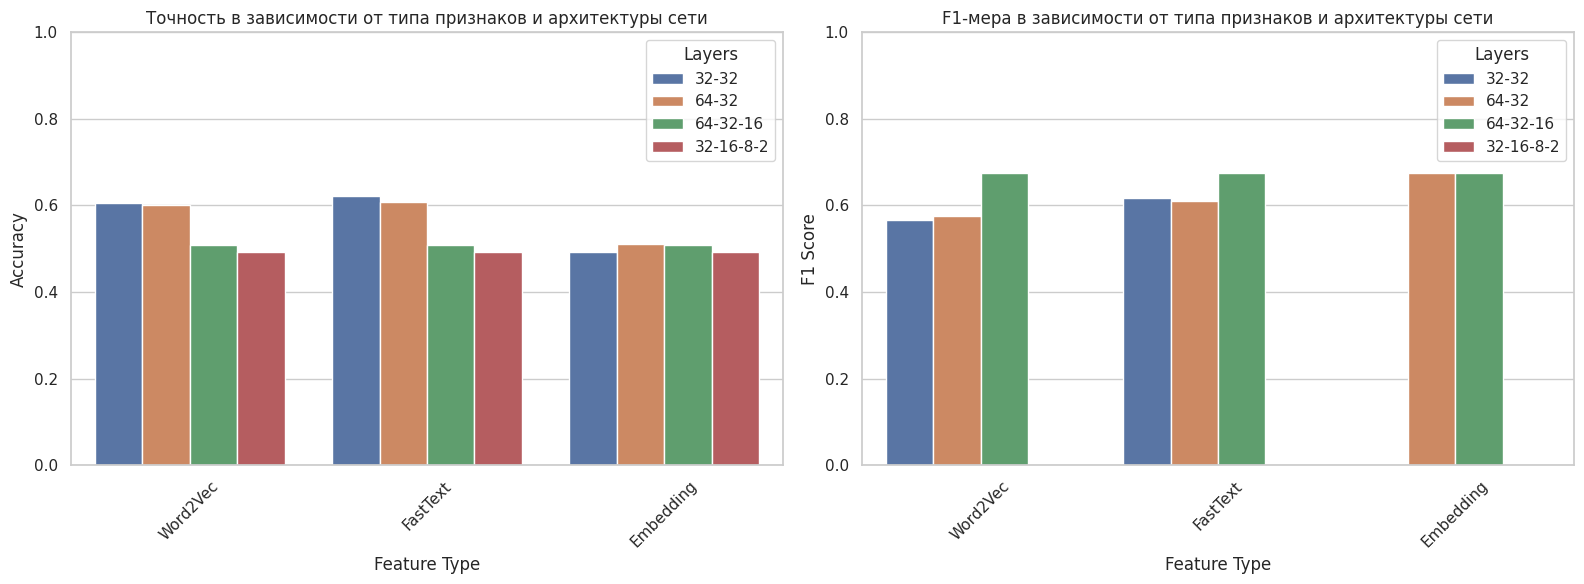

In [8]:
# Преобразуем результаты в DataFrame
results_df = pd.DataFrame(results)

sns.set(style="whitegrid")
plt.figure(figsize=(16, 6))

# Точность Accuracy
plt.subplot(1, 2, 1)
sns.barplot(data=results_df, x="Feature Type", y="Accuracy", hue="Layers")
plt.title("Точность в зависимости от типа признаков и архитектуры сети")
plt.ylim(0, 1)
plt.xticks(rotation=45)

# F1-мера
plt.subplot(1, 2, 2)
sns.barplot(data=results_df, x="Feature Type", y="F1 Score", hue="Layers")
plt.title("F1-мера в зависимости от типа признаков и архитектуры сети")
plt.ylim(0, 1)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [4]:
torch.save(X_emb, '/kaggle/working/embedding.pt')

In [6]:
# Преобразуем эмбеддинги в DataFrame
df_emb = pd.DataFrame(X_emb)

# Добавляем столбец type из исходного DataFrame
df_emb = pd.concat([df[['type']], df_emb], axis=1)

# Сохраняем в CSV
df_emb.to_csv("X_emb_with_type.csv", index=False)

# Выводы

1. Лучший практический результат: FastText + 32-32 + LR=0.01 — Accuracy = 0,6213, F1 = 0,6177

2. Оптимальный баланс между простотой и точностью достигается в архитектуре 32-32.

3. Глубокие сети (32-16-8-2) неэффективны — переобучение или сложности в обучении.

4. Слишком маленький LR (0.0001) понижает Accuracy, хотя иногда даёт высокий F1.

5. Модели, использующие обучаемые эмбеддинги (nn.Embedding) наименее эффективны.